# Task 2: Sparse Evolutionary Training (SET)

In the second task, students will implement Sparse Evolutionary Training (SET), which allows the sparse connectivity pattern to evolve during training. At regular intervals during training:
- Remove a fraction of the smallest magnitude weights
- Add the same number of new connections at random locations

This procedure maintains a constant sparsity level while enabling the network structure to adapt over time. Students should compare the performance of SET with the static sparse baseline.

## 0. Setup and Data Loading

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import joblib

In [2]:
# If running in Colab, uncomment these lines after uploading or mounting Drive.
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

PROJECT_DIR = "/content/drive/MyDrive/MIDS/Spring26/ECE685D_DL/final_project"
if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

print(os.listdir(PROJECT_DIR))

ModuleNotFoundError: No module named 'google'

In [ ]:
results_dir = os.path.join(PROJECT_DIR, "results")

print("Results exists:", os.path.exists(results_dir))
print("Results path:", results_dir)

Results exists: True
Results path: /content/drive/MyDrive/MIDS/Spring26/ECE685D_DL/final_project/results


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_pin_memory = torch.cuda.is_available()
num_workers = min(2, os.cpu_count() or 1)

print(f"Using device: {device}")
print(f"Project directory: {PROJECT_DIR}")

Using device: cuda
Project directory: /content/drive/MyDrive/MIDS/Spring26/ECE685D_DL/final_project


In [ ]:
from models import ResNetCIFAR

In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
    ]
)

trainset = torchvision.datasets.CIFAR10(
    root=os.path.join(PROJECT_DIR, "data"),
    train=True,
    download=True,
    transform=transform,
)
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
)

testset = torchvision.datasets.CIFAR10(
    root=os.path.join(PROJECT_DIR, "data"),
    train=False,
    download=True,
    transform=transform,
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=128,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=use_pin_memory,
)

classes = trainset.classes
print(f"Loaded CIFAR-10 with {len(classes)} classes.")

Loaded CIFAR-10 with 10 classes.


## 1. SET Configuration

In [ ]:
sparsity_levels = [0.90, 0.95, 0.98]
optimizers = ["sgd", "adam"]
prune_fraction = 0.30
rewire_interval = 1
epochs = 15

criterion = nn.CrossEntropyLoss()
output_dir = os.path.join(PROJECT_DIR, "results")
os.makedirs(output_dir, exist_ok=True)

print(f"Sparsity levels: {sparsity_levels}")
print(f"Optimizers: {optimizers}")
print(f"Prune fraction: {prune_fraction:.2f}")
print(f"Rewire interval: every {rewire_interval} epoch(s)")
print(f"Output directory: {output_dir}")

Sparsity levels: [0.9, 0.95, 0.98]
Optimizers: ['sgd', 'adam']
Prune fraction: 0.30
Rewire interval: every 1 epoch(s)
Output directory: /content/drive/MyDrive/MIDS/Spring26/ECE685D_DL/final_project/results


In [ ]:
def initialize_masks(model, sparsity):
    """Initialize binary masks for weight tensors based on target sparsity."""
    masks = {}
    for name, param in model.named_parameters():
        if "weight" in name and param.ndim > 1:
            mask = (torch.rand_like(param) > sparsity).float()
            masks[name] = mask
    return masks


def apply_masks(model, masks):
    """Zero out pruned weights by applying masks in-place."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name in masks:
                param.mul_(masks[name])


def apply_masks_to_grads(model, masks):
    """Keep pruned connections frozen by masking their gradients."""
    for name, param in model.named_parameters():
        if name in masks and param.grad is not None:
            param.grad.mul_(masks[name])


def prune_and_regrow(model, masks, prune_fraction):
    """Magnitude prune active weights, then randomly regrow the same count."""
    with torch.no_grad():
        for name, param in model.named_parameters():
            if name not in masks:
                continue

            weights = param
            mask = masks[name]

            active_positions = mask.nonzero(as_tuple=False)
            if active_positions.numel() == 0:
                continue

            active_weights = weights[mask.bool()]
            n_prune = int(active_weights.numel() * prune_fraction)
            if n_prune < 1:
                continue

            _, prune_indices = torch.topk(
                active_weights.abs(), k=n_prune, largest=False
            )
            prune_positions = active_positions[prune_indices]
            prune_index = tuple(
                prune_positions[:, dim] for dim in range(prune_positions.size(1))
            )

            mask[prune_index] = 0.0
            weights[prune_index] = 0.0

            zero_positions = (mask == 0).nonzero(as_tuple=False)
            if zero_positions.numel() == 0:
                continue

            n_grow = min(n_prune, zero_positions.size(0))
            grow_choices = torch.randperm(
                zero_positions.size(0), device=zero_positions.device
            )[:n_grow]
            grow_positions = zero_positions[grow_choices]
            grow_index = tuple(
                grow_positions[:, dim] for dim in range(grow_positions.size(1))
            )

            mask[grow_index] = 1.0
            std = weights.std()
            if std == 0:
                std = 0.01
            weights[grow_index] = torch.randn(n_grow, device=weights.device) * std


def build_sparse_model(sparsity):
    model = ResNetCIFAR().to(device)
    masks = initialize_masks(model, sparsity)
    apply_masks(model, masks)
    return model, masks

## 2. Train and Save Results

In [ ]:
def build_optimizer(model, optimizer_type):
    if optimizer_type == "sgd":
        return optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    if optimizer_type == "adam":
        return optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    raise ValueError(f"Unsupported optimizer: {optimizer_type}")


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total_examples += labels.size(0)
            total_correct += predicted.eq(labels).sum().item()

    average_loss = total_loss / len(loader)
    accuracy = 100.0 * total_correct / total_examples
    return average_loss, accuracy


all_results = {}

for opt_name in optimizers:
    all_results[opt_name] = {}
    for target_sparsity in sparsity_levels:
        print(
            f"\n===== SET Run | Sparsity={target_sparsity:.2f} | Optimizer={opt_name} ====="
        )

        model, masks = build_sparse_model(target_sparsity)
        optimizer = build_optimizer(model, opt_name)
        history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

        for epoch in range(epochs):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for inputs, labels in trainloader:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                apply_masks_to_grads(model, masks)
                optimizer.step()
                apply_masks(model, masks)

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

            if (epoch + 1) % rewire_interval == 0:
                prune_and_regrow(model, masks, prune_fraction)
                apply_masks(model, masks)

            total_active = sum(mask.sum().item() for mask in masks.values())
            total_possible = sum(mask.numel() for mask in masks.values())
            current_sparsity = 1 - total_active / total_possible

            train_loss = running_loss / len(trainloader)
            train_acc = 100.0 * correct / total
            test_loss, test_acc = evaluate(model, testloader, criterion)

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)

            print(
                f"Epoch [{epoch + 1}/{epochs}] | "
                f"Train Loss: {train_loss:.4f} | "
                f"Train Acc: {train_acc:.2f}% | "
                f"Test Loss: {test_loss:.4f} | "
                f"Test Acc: {test_acc:.2f}% | "
                f"Current Sparsity: {current_sparsity:.4f}"
            )

        experiment_results = {
            "sparsity": target_sparsity,
            "optimizer": opt_name,
            "method": "SET",
            "prune_fraction": prune_fraction,
            "rewire_interval": rewire_interval,
            "epochs": epochs,
            "train_loss": history["train_loss"],
            "train_acc": history["train_acc"],
            "test_loss": history["test_loss"],
            "test_acc": history["test_acc"],
            "masks": masks,
            "model_state": model.state_dict(),
        }

        results_path = os.path.join(
            PROJECT_DIR,
            "results",
            f"task_2_{opt_name}_{int(target_sparsity * 100)}_sparsity.joblib",
        )
        print("Saving to:", results_path)
        print("Exists parent folder:", os.path.exists(os.path.dirname(results_path)))
        joblib.dump(experiment_results, results_path)
        print(f"Saved results to {results_path}")

        all_results[opt_name][target_sparsity] = experiment_results

print("\nFinished all sparsity and optimizer runs.")


===== SET Run | Sparsity=0.90 | Optimizer=sgd =====
Epoch [1/15] | Train Loss: 1.4559 | Train Acc: 45.74% | Test Loss: 20.5726 | Test Acc: 10.05% | Current Sparsity: 0.8998
Epoch [2/15] | Train Loss: 1.0470 | Train Acc: 62.54% | Test Loss: 116.0259 | Test Acc: 10.00% | Current Sparsity: 0.8998
Epoch [3/15] | Train Loss: 0.9215 | Train Acc: 67.15% | Test Loss: 2.7552 | Test Acc: 31.00% | Current Sparsity: 0.8998
Epoch [4/15] | Train Loss: 0.8356 | Train Acc: 70.62% | Test Loss: 1.7673 | Test Acc: 45.78% | Current Sparsity: 0.8998
Epoch [5/15] | Train Loss: 0.7778 | Train Acc: 72.67% | Test Loss: 105.7905 | Test Acc: 9.66% | Current Sparsity: 0.8998
Epoch [6/15] | Train Loss: 0.7365 | Train Acc: 74.21% | Test Loss: 8.0821 | Test Acc: 18.04% | Current Sparsity: 0.8998
Epoch [7/15] | Train Loss: 0.7047 | Train Acc: 75.23% | Test Loss: 3.0432 | Test Acc: 22.18% | Current Sparsity: 0.8998
Epoch [8/15] | Train Loss: 0.6833 | Train Acc: 76.30% | Test Loss: 3.2431 | Test Acc: 24.69% | Current 

## 3. Analysis and Comparison Workflow

This section analyzes saved Task 1 (static sparse) and Task 2 (SET) joblib artifacts.

What this section covers:
- Training dynamics for SET across sparsity and optimizer settings
- Final Task 2 accuracy as sparsity increases
- Direct Task 1 vs Task 2 accuracy comparison
- Compact summary tables for reporting

How to use this section:
1. Run cells top to bottom.
2. Confirm all expected artifact files are loaded.
3. Use each plot's interpretation notes to explain trends in your report.

In [24]:
import gc
import os
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

%matplotlib inline

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.autolayout"] = True

# Force CPU deserialization so artifacts saved on GPU machines load everywhere.
_original_torch_load = torch.serialization.load


def cpu_torch_load(*args, **kwargs):
    kwargs["map_location"] = torch.device("cpu")
    return _original_torch_load(*args, **kwargs)


torch.load = cpu_torch_load

In [16]:
from pathlib import Path
import os
import sys


def infer_project_dir(start_path=None):
    start = Path(start_path or os.getcwd()).resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "models.py").exists() and (candidate / "results").exists():
            return candidate

    return start


PROJECT_DIR = infer_project_dir()

# avoid duplicate sys.path entries
project_dir_str = str(PROJECT_DIR)
if project_dir_str not in sys.path:
    sys.path.append(project_dir_str)

# ensure output folder exists
img_dir = os.path.join(PROJECT_DIR, "img")
os.makedirs(img_dir, exist_ok=True)

print(f"PROJECT_DIR: {PROJECT_DIR}")

PROJECT_DIR: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project


In [25]:
analysis_dir = os.path.join(PROJECT_DIR, "results")
analysis_sparsities = [0.90, 0.95, 0.98]
analysis_opts = ["sgd", "adam"]

print("Loading from:", analysis_dir)
print("Optimizers:", analysis_opts)
print("Sparsities:", analysis_sparsities)


def load_task_results(task_id, optimizers, sparsity_levels, output_dir):
    results = {opt: {} for opt in optimizers}

    for opt in optimizers:
        for s in sparsity_levels:
            file_path = os.path.join(
                output_dir,
                f"task_{task_id}_{opt}_{int(s * 100)}_sparsity.joblib",
            )

            if not os.path.exists(file_path):
                print(f"Missing: {file_path}")
                continue

            try:
                results[opt][s] = joblib.load(file_path, mmap_mode=None)
                print(f"Loaded: {file_path}")
            except Exception as e:
                print(f"Failed to load {file_path}: {e}")

    return results


results_task_1 = load_task_results(
    1,
    analysis_opts,
    analysis_sparsities,
    analysis_dir,
)
results_task_2 = load_task_results(
    2,
    analysis_opts,
    analysis_sparsities,
    analysis_dir,
)

print("\nSanity check:")
print("Task 1 optimizers:", list(results_task_1.keys()))
print("Task 2 optimizers:", list(results_task_2.keys()))
print("\nFinished loading analysis artifacts.")

Loading from: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results
Optimizers: ['sgd', 'adam']
Sparsities: [0.9, 0.95, 0.98]
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_sgd_90_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_sgd_95_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_sgd_98_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_adam_90_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_adam_95_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_1_adam_98_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_2_sgd_90_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE685D_Final_Project/results/task_2_sgd_95_sparsity.joblib
Loaded: /Users/ammylin/Desktop/ECE685D_DL/ECE

### Training Dynamics (Loss and Accuracy Curves)

What is shown:
- For each sparsity level (90%, 95%, 98%), four line charts are drawn:
  - Train loss vs epoch
  - Test loss vs epoch
  - Train accuracy vs epoch
  - Test accuracy vs epoch
- Each chart compares SGD and Adam.

How to interpret:
- Faster loss drop indicates quicker optimization.
- Large train/test gaps may indicate overfitting.
- Higher and more stable test accuracy indicates better generalization.
- Compare the same metric across sparsity levels to see how aggressive pruning affects learning.

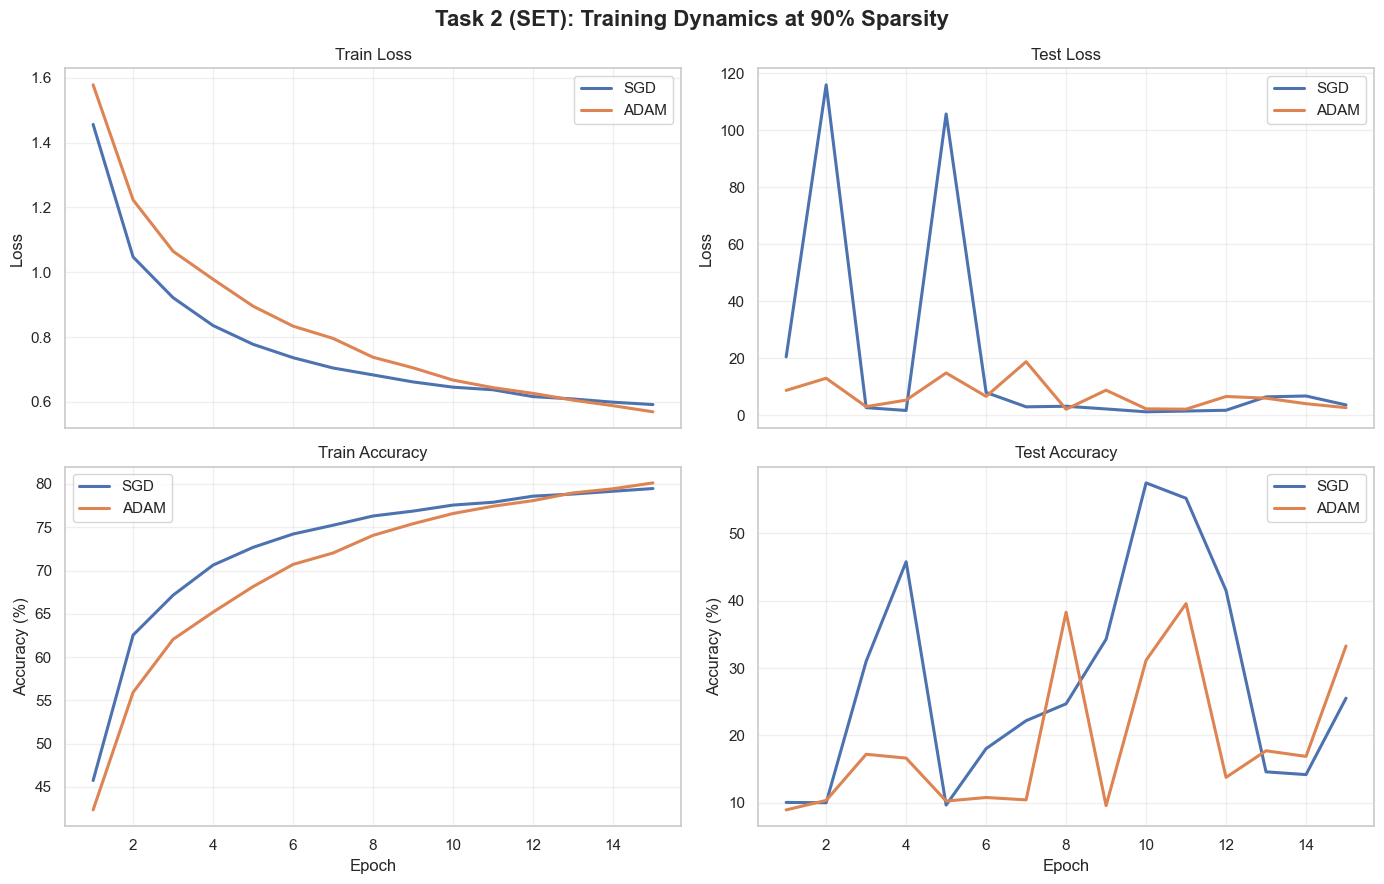

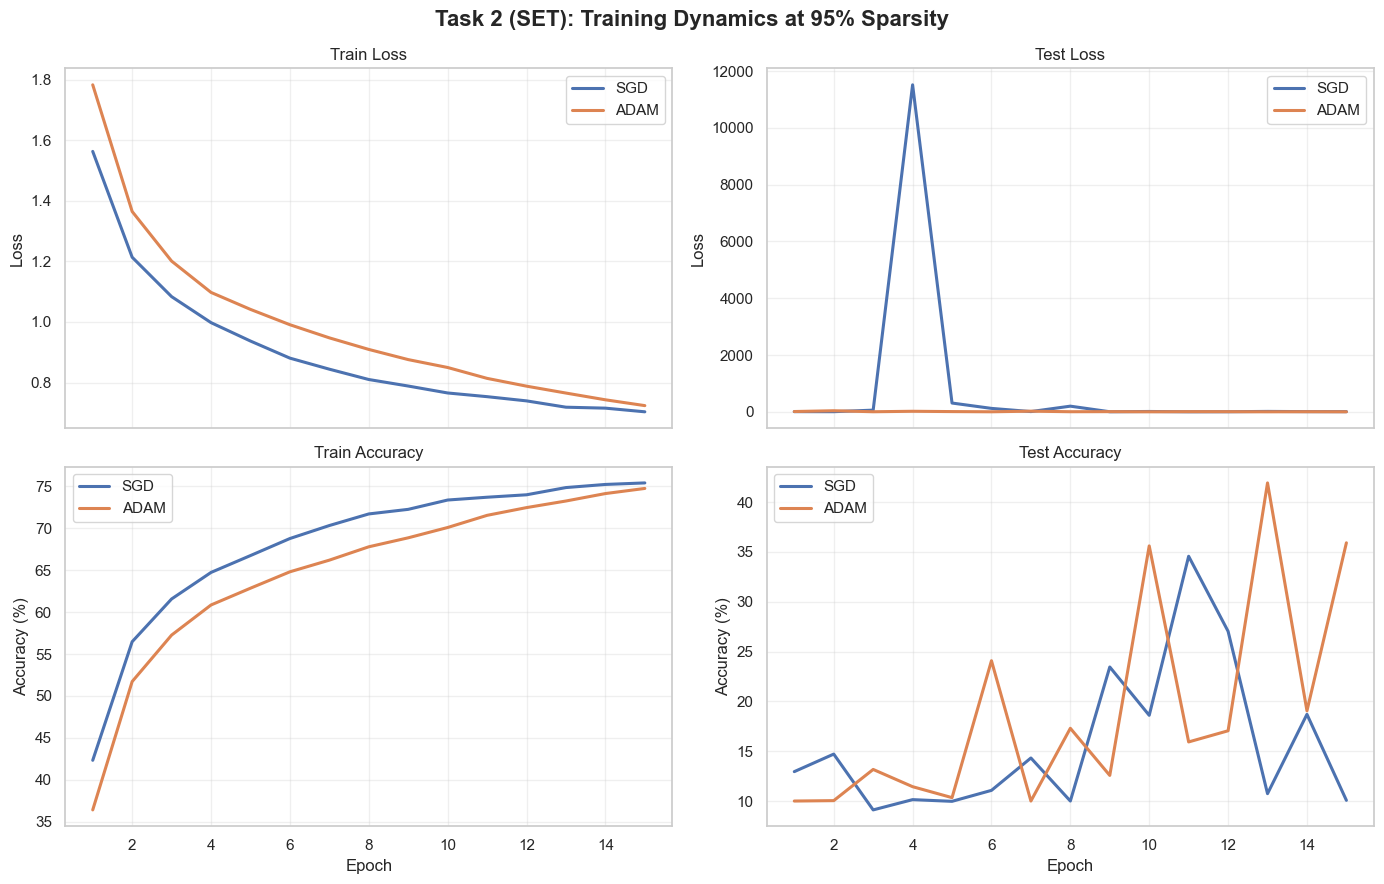

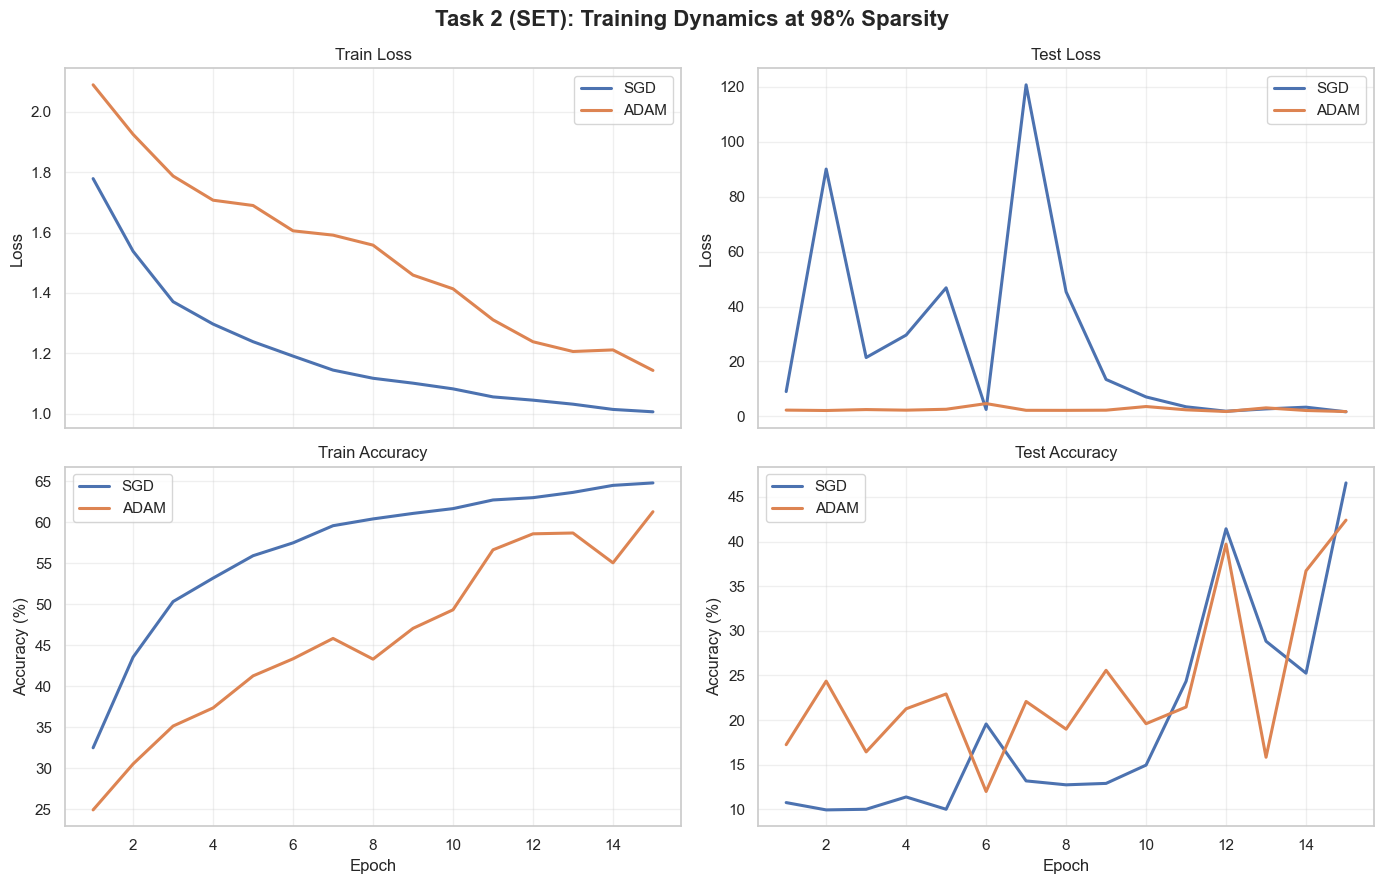

✓ Training dynamics completed


In [26]:
def plot_training_and_validation(results, task_label="Task 2 (SET)"):
    for s in analysis_sparsities:
        rows = []

        for opt in analysis_opts:
            if s in results[opt]:
                n_epochs = len(results[opt][s]["train_loss"])
                for epoch in range(n_epochs):
                    rows.append(
                        {
                            "epoch": epoch + 1,
                            "optimizer": opt.upper(),
                            "split": "Train",
                            "loss": results[opt][s]["train_loss"][epoch],
                            "accuracy": results[opt][s]["train_acc"][epoch],
                        }
                    )
                    rows.append(
                        {
                            "epoch": epoch + 1,
                            "optimizer": opt.upper(),
                            "split": "Test",
                            "loss": results[opt][s]["test_loss"][epoch],
                            "accuracy": results[opt][s]["test_acc"][epoch],
                        }
                    )

        if not rows:
            print(f"No runs available for sparsity={s:.2f}")
            continue

        df = pd.DataFrame(rows)

        fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
        fig.suptitle(
            f"{task_label}: Training Dynamics at {int(s * 100)}% Sparsity",
            fontsize=16,
            weight="bold",
        )

        sns.lineplot(
            data=df[df["split"] == "Train"],
            x="epoch",
            y="loss",
            hue="optimizer",
            linewidth=2.2,
            ax=axes[0, 0],
        )
        axes[0, 0].set_title("Train Loss")
        axes[0, 0].set_ylabel("Loss")
        axes[0, 0].legend(title="")

        sns.lineplot(
            data=df[df["split"] == "Test"],
            x="epoch",
            y="loss",
            hue="optimizer",
            linewidth=2.2,
            ax=axes[0, 1],
        )
        axes[0, 1].set_title("Test Loss")
        axes[0, 1].set_ylabel("Loss")
        axes[0, 1].legend(title="")

        sns.lineplot(
            data=df[df["split"] == "Train"],
            x="epoch",
            y="accuracy",
            hue="optimizer",
            linewidth=2.2,
            ax=axes[1, 0],
        )
        axes[1, 0].set_title("Train Accuracy")
        axes[1, 0].set_xlabel("Epoch")
        axes[1, 0].set_ylabel("Accuracy (%)")
        axes[1, 0].legend(title="")

        sns.lineplot(
            data=df[df["split"] == "Test"],
            x="epoch",
            y="accuracy",
            hue="optimizer",
            linewidth=2.2,
            ax=axes[1, 1],
        )
        axes[1, 1].set_title("Test Accuracy")
        axes[1, 1].set_xlabel("Epoch")
        axes[1, 1].set_ylabel("Accuracy (%)")
        axes[1, 1].legend(title="")

        for ax in axes.flat:
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(
            os.path.join(PROJECT_DIR, "img", f"task_2_curves_{int(s * 100)}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()


plot_training_and_validation(results_task_2, task_label="Task 2 (SET)")
gc.collect()
print("✓ Training dynamics completed")

### Final Accuracy vs Sparsity (Task 2)

What is shown:
- A line plot of final test accuracy versus sparsity for SGD and Adam.
- Point labels annotate exact final accuracy values.

How to interpret:
- Downward trend with higher sparsity means performance degrades as the model gets sparser.
- Smaller drop indicates better robustness to sparsity.
- Compare optimizer lines to identify which optimizer handles sparse SET training better at each sparsity target.

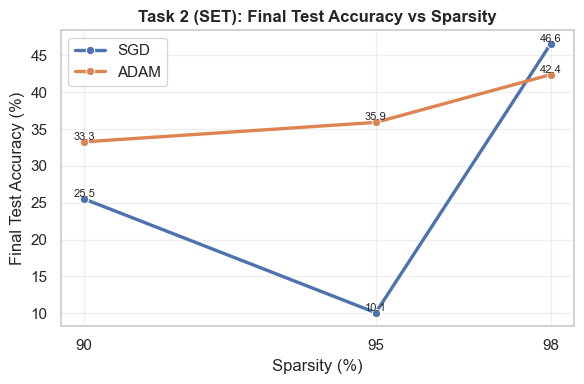

✓ Task 2 accuracy plot completed


In [27]:
def plot_accuracy_vs_sparsity(results, task_label="Task 2 (SET)"):
    rows = []
    for opt in analysis_opts:
        for s in analysis_sparsities:
            if s in results[opt]:
                rows.append(
                    {
                        "optimizer": opt.upper(),
                        "sparsity": int(s * 100),
                        "final_test_acc": results[opt][s]["test_acc"][-1],
                    }
                )

    if not rows:
        print("No data available for accuracy-vs-sparsity plot.")
        return None

    df = pd.DataFrame(rows)

    plt.figure(figsize=(6, 4))
    ax = sns.lineplot(
        data=df,
        x="sparsity",
        y="final_test_acc",
        hue="optimizer",
        marker="o",
        linewidth=2.4,
    )

    for _, row in df.iterrows():
        ax.text(
            row["sparsity"],
            row["final_test_acc"],
            f"{row['final_test_acc']:.1f}",
            fontsize=8,
            ha="center",
            va="bottom",
        )

    ax.set_title(f"{task_label}: Final Test Accuracy vs Sparsity", weight="bold")
    ax.set_xlabel("Sparsity (%)")
    ax.set_ylabel("Final Test Accuracy (%)")
    ax.set_xticks([90, 95, 98])
    ax.legend(title="")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_DIR, "img", "task_2_accuracy_vs_sparsity.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    return df.sort_values(["optimizer", "sparsity"]).reset_index(drop=True)


task2_summary = plot_accuracy_vs_sparsity(results_task_2, task_label="Task 2 (SET)")
gc.collect()
print("✓ Task 2 accuracy plot completed")

### Task 1 Static vs Task 2 SET Comparison

What is shown:
- Grouped bar chart of final test accuracy by sparsity for both methods.
- Heatmap of delta values: Task 2 accuracy minus Task 1 accuracy (percentage points).

How to interpret:
- In the bar chart, taller Task 2 bars suggest SET outperforms static sparse training.
- In the heatmap:
  - Positive values indicate SET improvement.
  - Negative values indicate SET underperformance.
  - Values near zero indicate similar outcomes.
- Patterns by optimizer help explain whether gains are optimizer-specific.

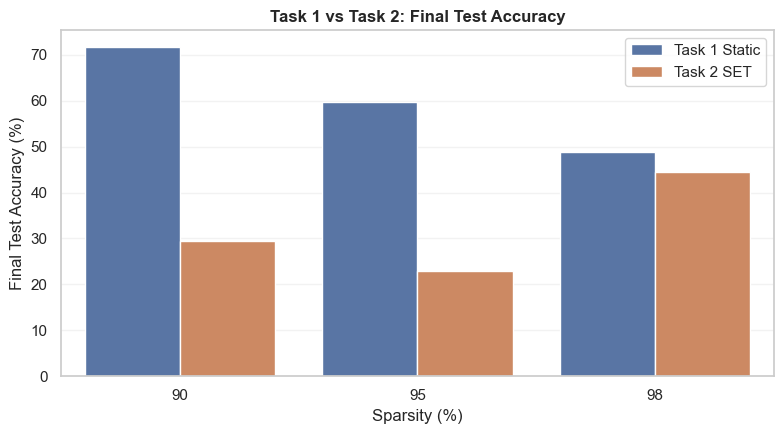

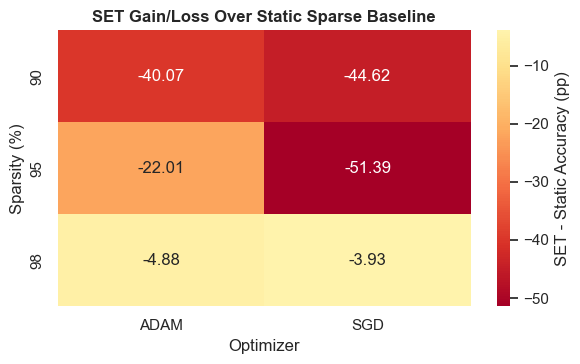

✓ Task comparison completed


In [28]:
def compare_task1_vs_task2(results_task_1, results_task_2):
    rows = []

    for opt in results_task_1.keys():
        if opt not in results_task_2:
            continue

        for s in results_task_1[opt].keys():
            if s not in results_task_2[opt]:
                continue

            baseline_list = results_task_1[opt][s].get("test_acc", [])
            set_list = results_task_2[opt][s].get("test_acc", [])
            if not baseline_list or not set_list:
                continue

            baseline_acc = baseline_list[-1]
            set_acc = set_list[-1]

            rows.append(
                {
                    "optimizer": opt.upper(),
                    "sparsity": int(float(s) * 100),
                    "task_1_static": baseline_acc,
                    "task_2_set": set_acc,
                    "delta_set_minus_static": set_acc - baseline_acc,
                }
            )

    if not rows:
        print("No overlapping Task 1/Task 2 runs found.")
        return None

    df = (
        pd.DataFrame(rows).sort_values(["optimizer", "sparsity"]).reset_index(drop=True)
    )

    long_df = df.melt(
        id_vars=["optimizer", "sparsity"],
        value_vars=["task_1_static", "task_2_set"],
        var_name="method",
        value_name="final_test_acc",
    )
    long_df["method"] = long_df["method"].map(
        {
            "task_1_static": "Task 1 Static",
            "task_2_set": "Task 2 SET",
        }
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.barplot(
        data=long_df,
        x="sparsity",
        y="final_test_acc",
        hue="method",
        errorbar=None,
        ax=ax,
    )
    ax.set_title("Task 1 vs Task 2: Final Test Accuracy", weight="bold")
    ax.set_xlabel("Sparsity (%)")
    ax.set_ylabel("Final Test Accuracy (%)")
    ax.grid(True, axis="y", alpha=0.25)
    ax.legend(title="")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_DIR, "img", "task_1_vs_task_2_accuracy.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    delta_pivot = df.pivot(
        index="sparsity",
        columns="optimizer",
        values="delta_set_minus_static",
    )

    fig, ax = plt.subplots(figsize=(6, 3.8))
    sns.heatmap(
        delta_pivot,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        cbar_kws={"label": "SET - Static Accuracy (pp)"},
        ax=ax,
    )
    ax.set_title("SET Gain/Loss Over Static Sparse Baseline", weight="bold")
    ax.set_xlabel("Optimizer")
    ax.set_ylabel("Sparsity (%)")
    plt.tight_layout()
    plt.savefig(
        os.path.join(PROJECT_DIR, "img", "task_2_delta_heatmap.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)

    return df


comparison_df = compare_task1_vs_task2(results_task_1, results_task_2)

gc.collect()
print("✓ Task comparison completed")

### Summary Tables and Reporting Notes

What is shown:
- Task 2 final accuracy table by optimizer and sparsity.
- Task 1 vs Task 2 comparison table with per-setting deltas.
- Average delta per optimizer.

How to interpret:
- Use the Task 2 summary table to identify the strongest sparsity-optimizer combinations.
- Use per-setting delta to discuss where SET helps most.
- Use average delta to provide a concise optimizer-level conclusion.

Suggested reporting structure:
1. Overall best-performing configuration.
2. Effect of increasing sparsity on final performance.
3. Whether SET consistently improves over the static baseline.

### Results Interpretation (Computed)

#### 1) Task 2 (SET) Final Accuracy
- ADAM: 33.27% (90%), 35.91% (95%), 42.40% (98%)
- SGD: 25.52% (90%), 10.07% (95%), 46.57% (98%)

Best Task 2 setting:
- SGD at 98% sparsity: 46.57%

Worst Task 2 setting:
- SGD at 95% sparsity: 10.07%

#### 2) Task 1 Static vs Task 2 SET
Delta is computed as: Task 2 minus Task 1 (percentage points).

- ADAM deltas: -40.07 (90%), -22.01 (95%), -4.88 (98%)
- SGD deltas: -44.62 (90%), -51.39 (95%), -3.93 (98%)

Average delta by optimizer:
- ADAM: -22.32 pp
- SGD: -33.31 pp

#### 3) Main Conclusions
1. In this run, SET underperforms static sparse training at all tested sparsities and for both optimizers.
2. The performance gap is very large at 90% and 95% sparsity, and becomes small at 98% sparsity.
3. Within Task 2 only, the best result occurs at 98% sparsity, suggesting this particular SET configuration did not translate train improvements into stable test performance at lower sparsity levels.
4. Training curves show smoother train optimization than test behavior, indicating unstable or weak generalization during these SET runs.

In [29]:
print("\n" + "=" * 60)
print("SUMMARY TABLES")
print("=" * 60)

if task2_summary is not None:
    print("\nTask 2 final accuracy summary:")
    display(task2_summary)

if comparison_df is not None:
    print("\nTask 1 vs Task 2 comparison:")
    display(comparison_df)

    print("\nAverage delta by optimizer:")
    display(
        comparison_df.groupby("optimizer", as_index=False)[
            "delta_set_minus_static"
        ].mean()
    )

print("\n" + "=" * 60)
print("Analysis pipeline completed")
print("=" * 60)


SUMMARY TABLES

Task 2 final accuracy summary:


,optimizer,sparsity,final_test_acc
0,ADAM,90,33.27
1,ADAM,95,35.91
2,ADAM,98,42.40
3,SGD,90,25.52
4,SGD,95,10.07
5,SGD,98,46.57



Task 1 vs Task 2 comparison:


,optimizer,sparsity,task_1_static,task_2_set,delta_set_minus_static
0,ADAM,90,73.34,33.27,-40.07
1,ADAM,95,57.92,35.91,-22.01
2,ADAM,98,47.28,42.40,-4.88
3,SGD,90,70.14,25.52,-44.62
4,SGD,95,61.46,10.07,-51.39
5,SGD,98,50.50,46.57,-3.93



Average delta by optimizer:


,optimizer,delta_set_minus_static
0,ADAM,-22.320000
1,SGD,-33.313333



Analysis pipeline completed


In [30]:
# Compact numeric summary for report write-up
print("Task 2 final accuracy table:")
print(task2_summary.to_string(index=False))

print("\nTask 1 vs Task 2 table:")
print(comparison_df.to_string(index=False))

avg_delta = comparison_df.groupby("optimizer", as_index=False)[
    "delta_set_minus_static"
].mean()
print("\nAverage delta (SET - Static) by optimizer:")
print(avg_delta.to_string(index=False))

best_task2 = task2_summary.sort_values("final_test_acc", ascending=False).iloc[0]
worst_task2 = task2_summary.sort_values("final_test_acc", ascending=True).iloc[0]
print("\nBest Task 2 setting:", dict(best_task2))
print("Worst Task 2 setting:", dict(worst_task2))

Task 2 final accuracy table:
optimizer  sparsity  final_test_acc
     ADAM        90           33.27
     ADAM        95           35.91
     ADAM        98           42.40
      SGD        90           25.52
      SGD        95           10.07
      SGD        98           46.57

Task 1 vs Task 2 table:
optimizer  sparsity  task_1_static  task_2_set  delta_set_minus_static
     ADAM        90          73.34       33.27                  -40.07
     ADAM        95          57.92       35.91                  -22.01
     ADAM        98          47.28       42.40                   -4.88
      SGD        90          70.14       25.52                  -44.62
      SGD        95          61.46       10.07                  -51.39
      SGD        98          50.50       46.57                   -3.93

Average delta (SET - Static) by optimizer:
optimizer  delta_set_minus_static
     ADAM              -22.320000
      SGD              -33.313333

Best Task 2 setting: {'optimizer': 'SGD', 'sparsit